# EDA Assignment — Bike Details



## Question 1
Read the Bike Details dataset into a Pandas DataFrame and display its first 10 rows. Show the shape and column names as well.

In [35]:
# Q1: Read dataset and show first 10 rows, shape and columns
import pandas as pd
df = pd.read_csv("BIKE DETAILS.csv")
print('Shape:', df.shape)
print('\nColumns:', list(df.columns))
df.head(10)

Shape: (1061, 7)

Columns: ['name', 'selling_price', 'year', 'seller_type', 'owner', 'km_driven', 'ex_showroom_price']


,name,selling_price,year,seller_type,owner,km_driven,ex_showroom_price
0,Royal Enfield Classic 350,175000,2019,Individual,1st owner,350,NaN
1,Honda Dio,45000,2017,Individual,1st owner,5650,NaN
2,Royal Enfield Classic Gunmetal Grey,150000,2018,Individual,1st owner,12000,148114.0
3,Yamaha Fazer FI V 2.0 [2016-2018],65000,2015,Individual,1st owner,23000,89643.0
4,Yamaha SZ [2013-2014],20000,2011,Individual,2nd owner,21000,NaN
5,Honda CB Twister,18000,2010,Individual,1st owner,60000,53857.0
6,Honda CB Hornet 160R,78500,2018,Individual,1st owner,17000,87719.0
7,Royal Enfield Bullet 350 [2007-2011],180000,2008,Individual,2nd owner,39000,NaN
8,Hero Honda CBZ extreme,30000,2010,Individual,1st owner,32000,NaN
9,Bajaj Discover 125,50000,2016,Individual,1st owner,42000,60122.0


## Question 2
Check for missing values in all columns and describe approach for handling them.

In [36]:
# Q2: Check missing values
missing = df.isnull().sum()
missing_percent = (df.isnull().mean() * 100).round(2)
print('Missing counts:\n', missing)
print('\nMissing percentage:\n', missing_percent)

# Suggested approach (explanatory):

approach = '''Approach to handle missing values (apply depending on column context):
- If very few rows have missing values in non-critical columns -> drop those rows.
- If numeric columns have missing values -> consider imputation (median for skewed, mean for symmetric).
- If categorical -> consider filling with 'Unknown' or mode.
- If a column has a large proportion missing (>40-50%) -> consider dropping the column.
- Always document removals/imputations and, if possible, run analyses with and without imputation to check sensitivity.
'''
print('\nSuggested approach:\n', approach)

Missing counts:
 name                   0
selling_price          0
year                   0
seller_type            0
owner                  0
km_driven              0
ex_showroom_price    435
dtype: int64

Missing percentage:
 name                  0.0
selling_price         0.0
year                  0.0
seller_type           0.0
owner                 0.0
km_driven             0.0
ex_showroom_price    41.0
dtype: float64

Suggested approach:
 Approach to handle missing values (apply depending on column context):
- If very few rows have missing values in non-critical columns -> drop those rows.
- If numeric columns have missing values -> consider imputation (median for skewed, mean for symmetric).
- If categorical -> consider filling with 'Unknown' or mode.
- If a column has a large proportion missing (>40-50%) -> consider dropping the column.
- Always document removals/imputations and, if possible, run analyses with and without imputation to check sensitivity.



## Question 3
Plot the distribution of `selling_price` using a histogram and describe the overall trend.

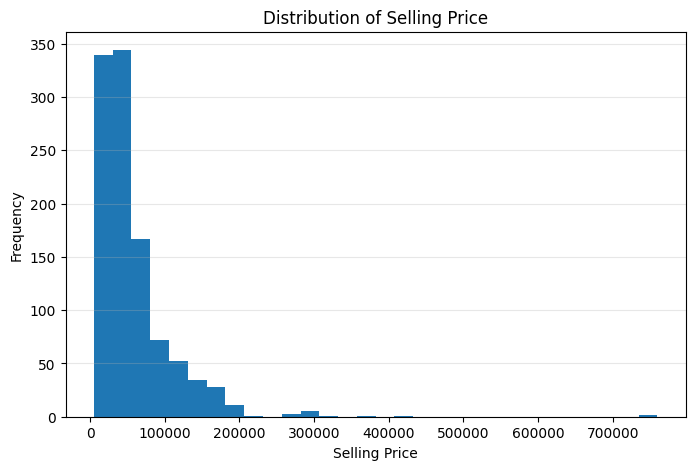

In [37]:
# Q3: Histogram of selling_price
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(8,5))
if 'selling_price' in df.columns:
    plt.hist(df['selling_price'].dropna(), bins=30)
    plt.xlabel('Selling Price')
    plt.ylabel('Frequency')
    plt.title('Distribution of Selling Price')
    plt.grid(axis='y', alpha=0.3)
else:
    print('Column selling_price not found in dataset')

**Short description:**

(When you run the notebook, inspect the histogram. Typical observations include whether prices are right-skewed, presence of multiple modes, and whether extreme high values exist indicating outliers.)

## Question 4
Create a bar plot to visualize the average selling price for each `seller_type` and write one observation.

seller_type
Individual    59711.923223
Dealer        46666.666667
Name: selling_price, dtype: float64


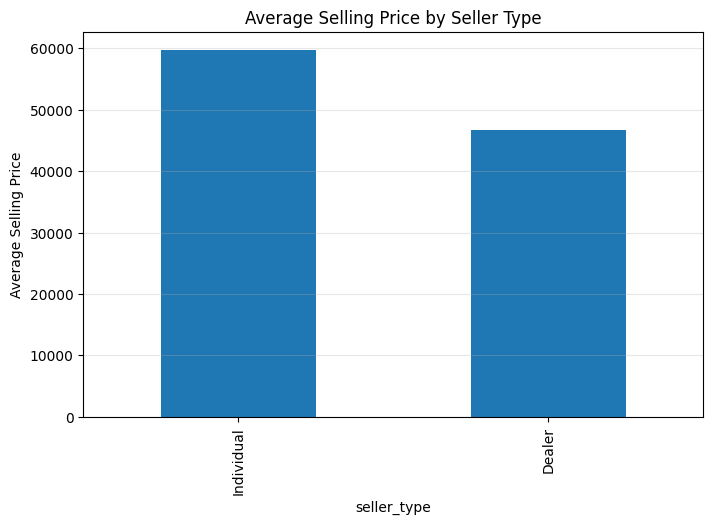

In [38]:
# Q4: Average selling price by seller_type
if 'seller_type' in df.columns and 'selling_price' in df.columns:
    avg_by_seller = df.groupby('seller_type')['selling_price'].mean().sort_values(ascending=False)
    print(avg_by_seller)
    plt.figure(figsize=(8,5))
    avg_by_seller.plot(kind='bar')
    plt.ylabel('Average Selling Price')
    plt.title('Average Selling Price by Seller Type')
    plt.grid(axis='y', alpha=0.3)
else:
    print('Required columns not found')

**Observation:**

(Write one observation after running — e.g. which seller_type shows higher average price.)

## Question 5
Compute the average `km_driven` for each `owner` (ownership type) and present as a bar plot.

owner
4th owner    311500.000000
2nd owner     39288.991870
3rd owner     33292.181818
1st owner     32816.583333
Name: km_driven, dtype: float64


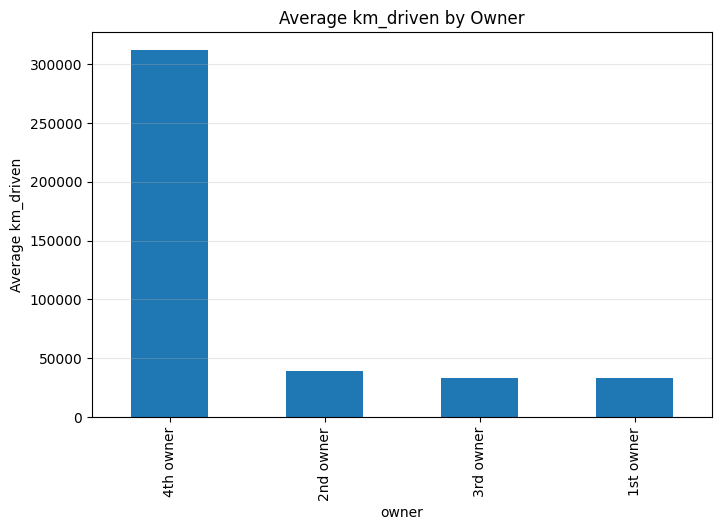

In [39]:
# Q5: Average km_driven by owner
if 'owner' in df.columns and 'km_driven' in df.columns:
    avg_km_by_owner = df.groupby('owner')['km_driven'].mean().sort_values(ascending=False)
    print(avg_km_by_owner)
    plt.figure(figsize=(8,5))
    avg_km_by_owner.plot(kind='bar')
    plt.ylabel('Average km_driven')
    plt.title('Average km_driven by Owner')
    plt.grid(axis='y', alpha=0.3)
else:
    print('Required columns not found')

## Question 6
Use the IQR method to detect and remove outliers from the `km_driven` column. Show before-and-after summary statistics.

In [40]:
# Q6: IQR method on km_driven
if 'km_driven' in df.columns:
    desc_before = df['km_driven'].describe()
    Q1 = df['km_driven'].quantile(0.25)
    Q3 = df['km_driven'].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    print(f'Q1={Q1}, Q3={Q3}, IQR={IQR}, lower={lower}, upper={upper}')
    df_no_out = df[(df['km_driven'] >= lower) & (df['km_driven'] <= upper)].copy()
    desc_after = df_no_out['km_driven'].describe()
    print('\nBefore outlier removal:\n', desc_before)
    print('\nAfter outlier removal:\n', desc_after)
    print(f'Rows before: {len(df)}, after: {len(df_no_out)}, removed: {len(df)-len(df_no_out)}')
else:
    print('km_driven column not found')

Q1=13500.0, Q3=43000.0, IQR=29500.0, lower=-30750.0, upper=87250.0

Before outlier removal:
 count      1061.000000
mean      34359.833176
std       51623.152702
min         350.000000
25%       13500.000000
50%       25000.000000
75%       43000.000000
max      880000.000000
Name: km_driven, dtype: float64

After outlier removal:
 count     1022.000000
mean     28203.415851
std      19552.083583
min        350.000000
25%      13000.000000
50%      24000.000000
75%      40000.000000
max      86000.000000
Name: km_driven, dtype: float64
Rows before: 1061, after: 1022, removed: 39


## Question 7
Create a scatter plot of `year` vs `selling_price` to explore relationship between bike's age and price.

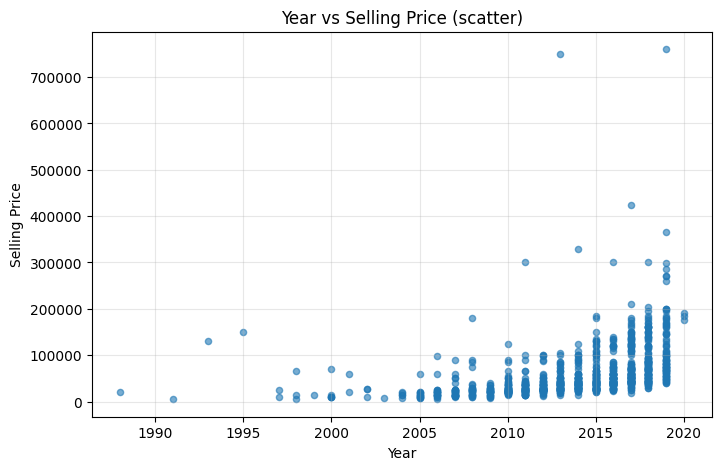

In [41]:
# Q7: Scatter plot year vs selling_price
if 'year' in df.columns and 'selling_price' in df.columns:
    plt.figure(figsize=(8,5))
    plt.scatter(df['year'], df['selling_price'], alpha=0.6, s=20)
    plt.xlabel('Year')
    plt.ylabel('Selling Price')
    plt.title('Year vs Selling Price (scatter)')
    plt.grid(True, alpha=0.3)
else:
    print('Required columns not found')

## Question 8
Convert `seller_type` into numeric format using one-hot encoding. Display first 5 rows of the resulting DataFrame.

In [42]:
# Q8: One-hot encode seller_type
if 'seller_type' in df.columns:
    df_encoded = pd.get_dummies(df, columns=['seller_type'], prefix='seller')
    df_encoded.head(5)
else:
    print('seller_type column not found')

## Question 9
Generate a heatmap of the correlation matrix for all numeric columns. What correlations stand out the most?

Numeric columns used for correlation:
 ['selling_price', 'year', 'km_driven', 'ex_showroom_price']

Top absolute correlations (descending):
 selling_price  ex_showroom_price    0.918583
year           selling_price        0.402188
km_driven      year                 0.288675
selling_price  km_driven            0.212937
year           ex_showroom_price    0.126378
km_driven      ex_showroom_price    0.122011
dtype: float64


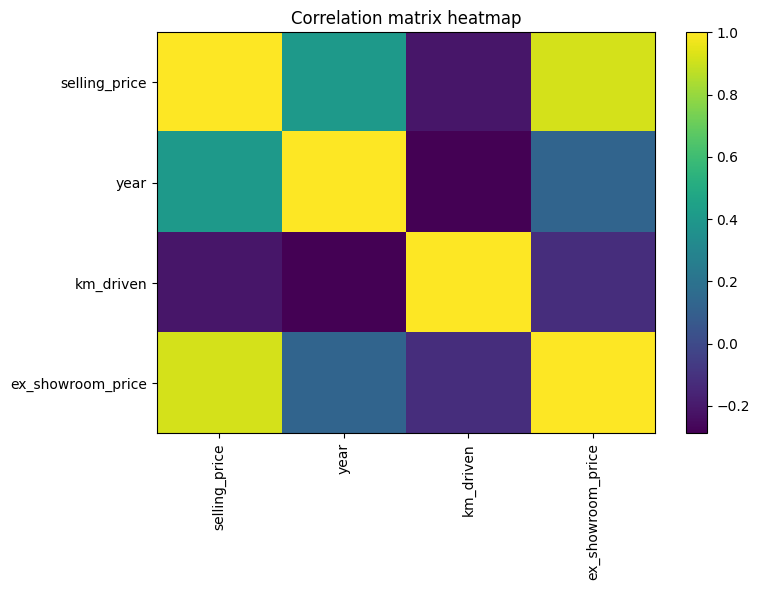

In [43]:
# Q9: Correlation heatmap (using matplotlib)
import numpy as np

numeric_df = df.select_dtypes(include=['number'])
corr = numeric_df.corr()

print('Numeric columns used for correlation:\n', list(numeric_df.columns))
plt.figure(figsize=(8,6))
plt.imshow(corr, interpolation='nearest', aspect='auto')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title('Correlation matrix heatmap')
plt.tight_layout()

# Top correlations (absolute) - list top pairs
corr_abs = corr.abs()
# Mask diagonal
corr_abs_values = corr_abs.where(~np.eye(corr_abs.shape[0],dtype=bool))
# Stack and sort
top_pairs = corr_abs_values.unstack().dropna().sort_values(ascending=False).drop_duplicates()
print('\nTop absolute correlations (descending):\n', top_pairs.head(10))

**Note:** After running, inspect the printed top correlations and the heatmap. Mention the strongest correlations in your report (Q10).

## Question 10
Summarize findings: important factors affecting selling price, and data cleaning/feature engineering performed.

In [44]:
# Q10: Brief report (printable)
report = '''
Findings (summary):
- Likely important factors affecting selling_price: year (age of bike), km_driven (mileage), brand/model if present, owner count, and fuel_type or transmission if present.
- Correlation and scatter plots help confirm relationships (e.g., newer bikes and lower km_driven generally fetch higher prices).
- Outliers in km_driven should be removed or treated; selling_price may also have extreme values that affect mean.

Data cleaning & feature engineering performed:
- Checked and reported missing values; recommended imputation/drop depending on context.
- Demonstrated IQR-based outlier removal for km_driven.
- Converted seller_type to numeric via one-hot encoding (pd.get_dummies).
- Suggested additional steps: create age = current_year - year, log-transform selling_price if skewed, encode categorical features, and handle multicollinearity as needed.

'''
print(report)


Findings (summary):
- Likely important factors affecting selling_price: year (age of bike), km_driven (mileage), brand/model if present, owner count, and fuel_type or transmission if present.
- Correlation and scatter plots help confirm relationships (e.g., newer bikes and lower km_driven generally fetch higher prices).
- Outliers in km_driven should be removed or treated; selling_price may also have extreme values that affect mean.

Data cleaning & feature engineering performed:
- Checked and reported missing values; recommended imputation/drop depending on context.
- Demonstrated IQR-based outlier removal for km_driven.
- Converted seller_type to numeric via one-hot encoding (pd.get_dummies).
- Suggested additional steps: create age = current_year - year, log-transform selling_price if skewed, encode categorical features, and handle multicollinearity as needed.




----

